In [28]:
from pathlib import Path
import matplotlib.pyplot as plt


experiment_path = Path('../rapid-geostrophic-reconstruction/figs/')

# Performance experiment

experiment_10d = 'experiment_20250228_065340'
experiment_30d = 'experiment_20250228_075230'
experiment_90d = 'experiment_20250228_065334'
experiment_365d = 'experiment_20250228_074151'

# experiment_deep_10d = 'experiment_20250109_103555'
# experiment_deep_30d = 'experiment_20250109_103008'
# experiment_deep_90d = 'experiment_20250109_102530'


# Geostorphic experiment 
# experiment_10d = 'experiment_20250106_154841'
# experiment_30d = 'experiment_20250106_142424'
# experiment_90d = 'experiment_20250106_160734'

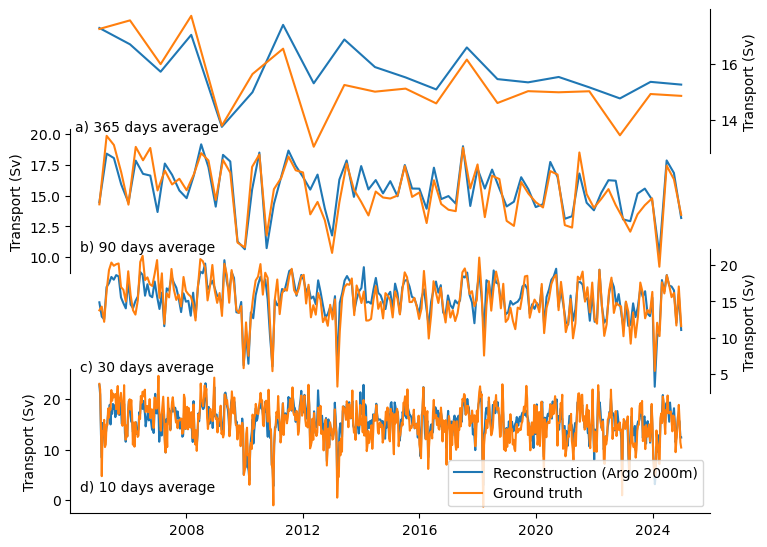

In [29]:
import xarray as xr
test_predictions_10d = xr.open_dataset(experiment_path / experiment_10d / 'ensemble_predictions.nc').mean('member')
test_predictions_30d = xr.open_dataset(experiment_path / experiment_30d / 'ensemble_predictions.nc').mean('member')
test_predictions_90d = xr.open_dataset(experiment_path / experiment_90d / 'ensemble_predictions.nc').mean('member')
test_predictions_365d = xr.open_dataset(experiment_path / experiment_365d / 'ensemble_predictions.nc').mean('member')

if 'experiment_deep_10d' in globals():
    test_predictions_deep_10d = xr.open_dataset(experiment_path / experiment_deep_10d / 'test_predictions.nc')
    test_predictions_deep_30d = xr.open_dataset(experiment_path / experiment_deep_30d / 'test_predictions.nc')
    test_predictions_deep_90d = xr.open_dataset(experiment_path / experiment_deep_90d / 'test_predictions.nc')


fig = plt.figure()
ax = fig.add_axes([0, 0, 1, .3])

ax.plot(test_predictions_10d.time, test_predictions_10d.test_predictions, label = 'Reconstruction (Argo 2000m)')
# ax.plot(test_predictions_deep_10d.time, test_predictions_deep_10d.test_predictions, label='Reconstruction (Deep Argo)')
ax.plot(test_predictions_10d.time, test_predictions_10d.test_gt_transport, label='Ground truth')


# remove the x-axis and also the border
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# ax.spines['bottom'].set_visible(False)

# ax.set_xticks([])

ax.legend(loc = 'lower right')

ax.text(0.12, 0.18, 'd) 10 days average', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)


ax.set_ylabel('Transport (Sv)')


ax = fig.add_axes([0, 0.25, 1, .3])

ax.plot(test_predictions_30d.time, test_predictions_30d.test_predictions, label = 'Reconstruction')
# ax.plot(test_predictions_deep_30d.time, test_predictions_deep_30d.test_predictions, label='Reconstruction (Deep Argo)')
ax.plot(test_predictions_30d.time, test_predictions_30d.test_gt_transport, label='Ground truth')


# remove the x-axis and also the border
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

ax.set_xticks([])
ax.text(0.12, 0.18, 'c) 30 days average', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)

#set y axis on right
ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")
ax.set_facecolor('none')
ax.set_ylabel('Transport (Sv)')

ax = fig.add_axes([0, 0.5, 1, .3])

ax.plot(test_predictions_90d.time, test_predictions_90d.test_predictions, label = 'Reconstruction')
# ax.plot(test_predictions_deep_90d.time, test_predictions_deep_90d.test_predictions, label='Reconstruction (Deep Argo)')
ax.plot(test_predictions_90d.time, test_predictions_90d.test_gt_transport, label='Ground truth')


# remove the x-axis and also the border
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

ax.set_xticks([])

ax.set_ylabel('Transport (Sv)')

#set background color to transparent
ax.set_facecolor('none')
ax.text(0.12, 0.18, 'b) 90 days average', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)

ax = fig.add_axes([0, 0.75, 1, .3])

ax.plot(test_predictions_365d.time, test_predictions_365d.test_predictions, label = 'Reconstruction')
# ax.plot(test_predictions_deep_90d.time, test_predictions_deep_90d.test_predictions, label='Reconstruction (Deep Argo)')
ax.plot(test_predictions_365d.time, test_predictions_365d.test_gt_transport, label='Ground truth')


# remove the x-axis and also the border
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

ax.set_xticks([])

ax.set_ylabel('Transport (Sv)')

#set background color to transparent
ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")
ax.set_facecolor('none')
ax.text(0.12, 0.18, 'a) 365 days average', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)

# fig.tight_layout()


# plt.savefig('../rapid-geostrophic-reconstruction/figs/transport_reconstruction.png', dpi=300)

# save complete figure

# fig.savefig('../rapid-geostrophic-reconstruction/figs/transport_reconstruction.png', dpi=300)


fig.savefig('../rapid-geostrophic-reconstruction/figs/transport_reconstruction.png', dpi=300, bbox_inches='tight')



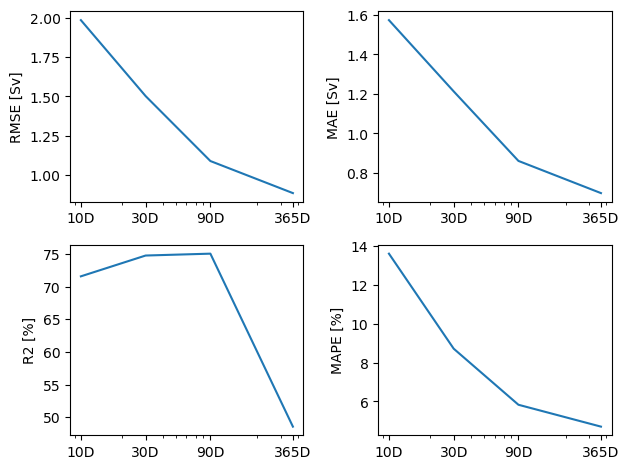

In [33]:
## Draw the metric plots 

fig = plt.figure()
ax = fig.add_subplot(2,2,1)

values = [
    (10, test_predictions_10d),
    (30, test_predictions_30d),
    (90, test_predictions_90d),
    (365, test_predictions_365d)
]

ax.plot([i[0] for i in values],[i[1]['rmse'] for i in values ], label = 'RMSE')
ax.set_xscale('log')
ax.set_xticks([i[0] for i in values])
ax.set_xticklabels([f'{i[0]}D' for i in values])
ax.set_ylabel('RMSE [Sv]')

ax = fig.add_subplot(2,2,2)
ax.plot([i[0] for i in values],[i[1]['mae'] for i in values ], label = 'MAE')
ax.set_xscale('log')
ax.set_xticks([i[0] for i in values])
ax.set_xticklabels([f'{i[0]}D' for i in values])
ax.set_ylabel('MAE [Sv]')

ax = fig.add_subplot(2,2,3)
ax.plot([i[0] for i in values],[i[1]['r2'] * 100 for i in values ], label = 'R2')
ax.set_xscale('log')
ax.set_xticks([i[0] for i in values])
ax.set_xticklabels([f'{i[0]}D' for i in values])
ax.set_ylabel('R2 [%]')

ax = fig.add_subplot(2,2,4)
ax.plot([i[0] for i in values],[i[1]['mape'] * 100 for i in values ], label = 'MAPE')
ax.set_xscale('log')
ax.set_xticks([i[0] for i in values])
ax.set_xticklabels([f'{i[0]}D' for i in values])
ax.set_ylabel('MAPE [%]')

fig.tight_layout()

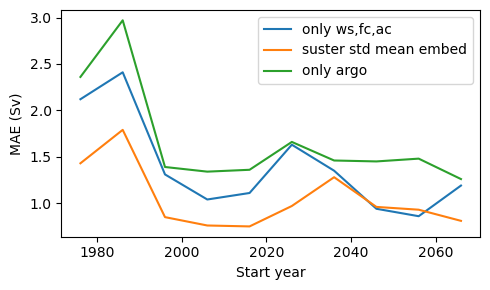

In [4]:
## crossvalidation figure 


## read the file

with open('../rapid-geostrophic-reconstruction/result_crossvalidation.txt', 'r') as f:
    lines = f.readlines()

looking_for = 'MAE'

v6_wo_argo = []
v5_std_mean_embed = []
v6_aux = []

for line in lines:

    if line.startswith('v6-wo'):
        splits = line.split(' ')
        years = splits[1]

        start_year = float(years.split('-')[0])

        if looking_for == 'R2':
            results = float(line.split('%')[0].split(' ')[-1])
        elif looking_for == 'MAE':
            results = float(line.split('MAE')[1].split(' ')[2])

        v6_wo_argo.append((start_year, results))
    elif line.startswith('v5-std-'):
        splits = line.split(' ')
        years = splits[1]

        start_year = float(years.split('-')[0])

        if looking_for == 'R2':
            results = float(line.split('%')[0].split(' ')[-1])
        elif looking_for == 'MAE':
            results = float(line.split('MAE')[1].split(' ')[2])

        v5_std_mean_embed.append((start_year, results))


    elif line.startswith('v6-aux'):
        splits = line.split(' ')
        years = splits[1]

        start_year = float(years.split('-')[0])

        if looking_for == 'R2':
            results = float(line.split('%')[0].split(' ')[-1])
        elif looking_for == 'MAE':
            results = float(line.split('MAE')[1].split(' ')[2])

        v6_aux.append((start_year, results))
import numpy as np
v6_wo_argo = np.array(v6_wo_argo)
v5_std_mean_embed = np.array(v5_std_mean_embed)
v6_aux = np.array(v6_aux)

import matplotlib.pyplot as plt
fig = plt.figure(figsize = (5,3))
ax = fig.add_subplot(1,1,1)


def plot_data(data, label):
    ax.plot(data[:,0], data[:,1], label=label)

plot_data(v6_wo_argo, 'only ws,fc,ac')
plot_data(v5_std_mean_embed, 'suster std mean embed')
plot_data(v6_aux, 'only argo')

ax.legend()
# ax.set_title('Using wind vs. wind, fc, ac for the reconstruction of totalMOC-geostrophicMOC')

ax.set_xlabel('Start year')
if looking_for == 'R2':
    ax.set_ylabel('R2 (%)')
    ax.set_ylim(0, 100)
    ax.grid(which='major', axis = 'y')
elif looking_for == 'MAE':
    ax.set_ylabel('MAE (Sv)')
fig.tight_layout()
plt.savefig(f'../rapid-geostrophic-reconstruction/figs/crossvalidation_{looking_for}.png', dpi=300)


In [4]:
a = [74.82, 79.15, 74.13, 78.63, 80.02]


b = [82.77, 79.40, 80.09, 81.81, 83.55]


from scipy.stats import ttest_ind
ttest_ind(a, b)

Ttest_indResult(statistic=-2.912290385262547, pvalue=0.01952047010782892)